# ChainUQ paper visualizations
This notebook generates two independent, compact mechanism figures from the cached 31-cell experiment matrix. Each PDF can be placed independently in LaTeX.

In [30]:
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import numpy as np

repo = Path.cwd().resolve()
if repo.name == 'visualization':
    repo = repo.parent
sys.path.insert(0, str(repo))
from acd.env import EXP_ROOT
from acd.features import _eq

out = repo / 'latex' / 'figures'
out.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix', 'font.size': 24,
    'axes.labelsize': 24, 'axes.titlesize': 24,
    'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'axes.spines.top': True, 'axes.spines.right': True,
    'axes.linewidth': 1.0, 'xtick.direction': 'in', 'ytick.direction': 'in',
    'figure.dpi': 300, 'savefig.dpi': 400,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

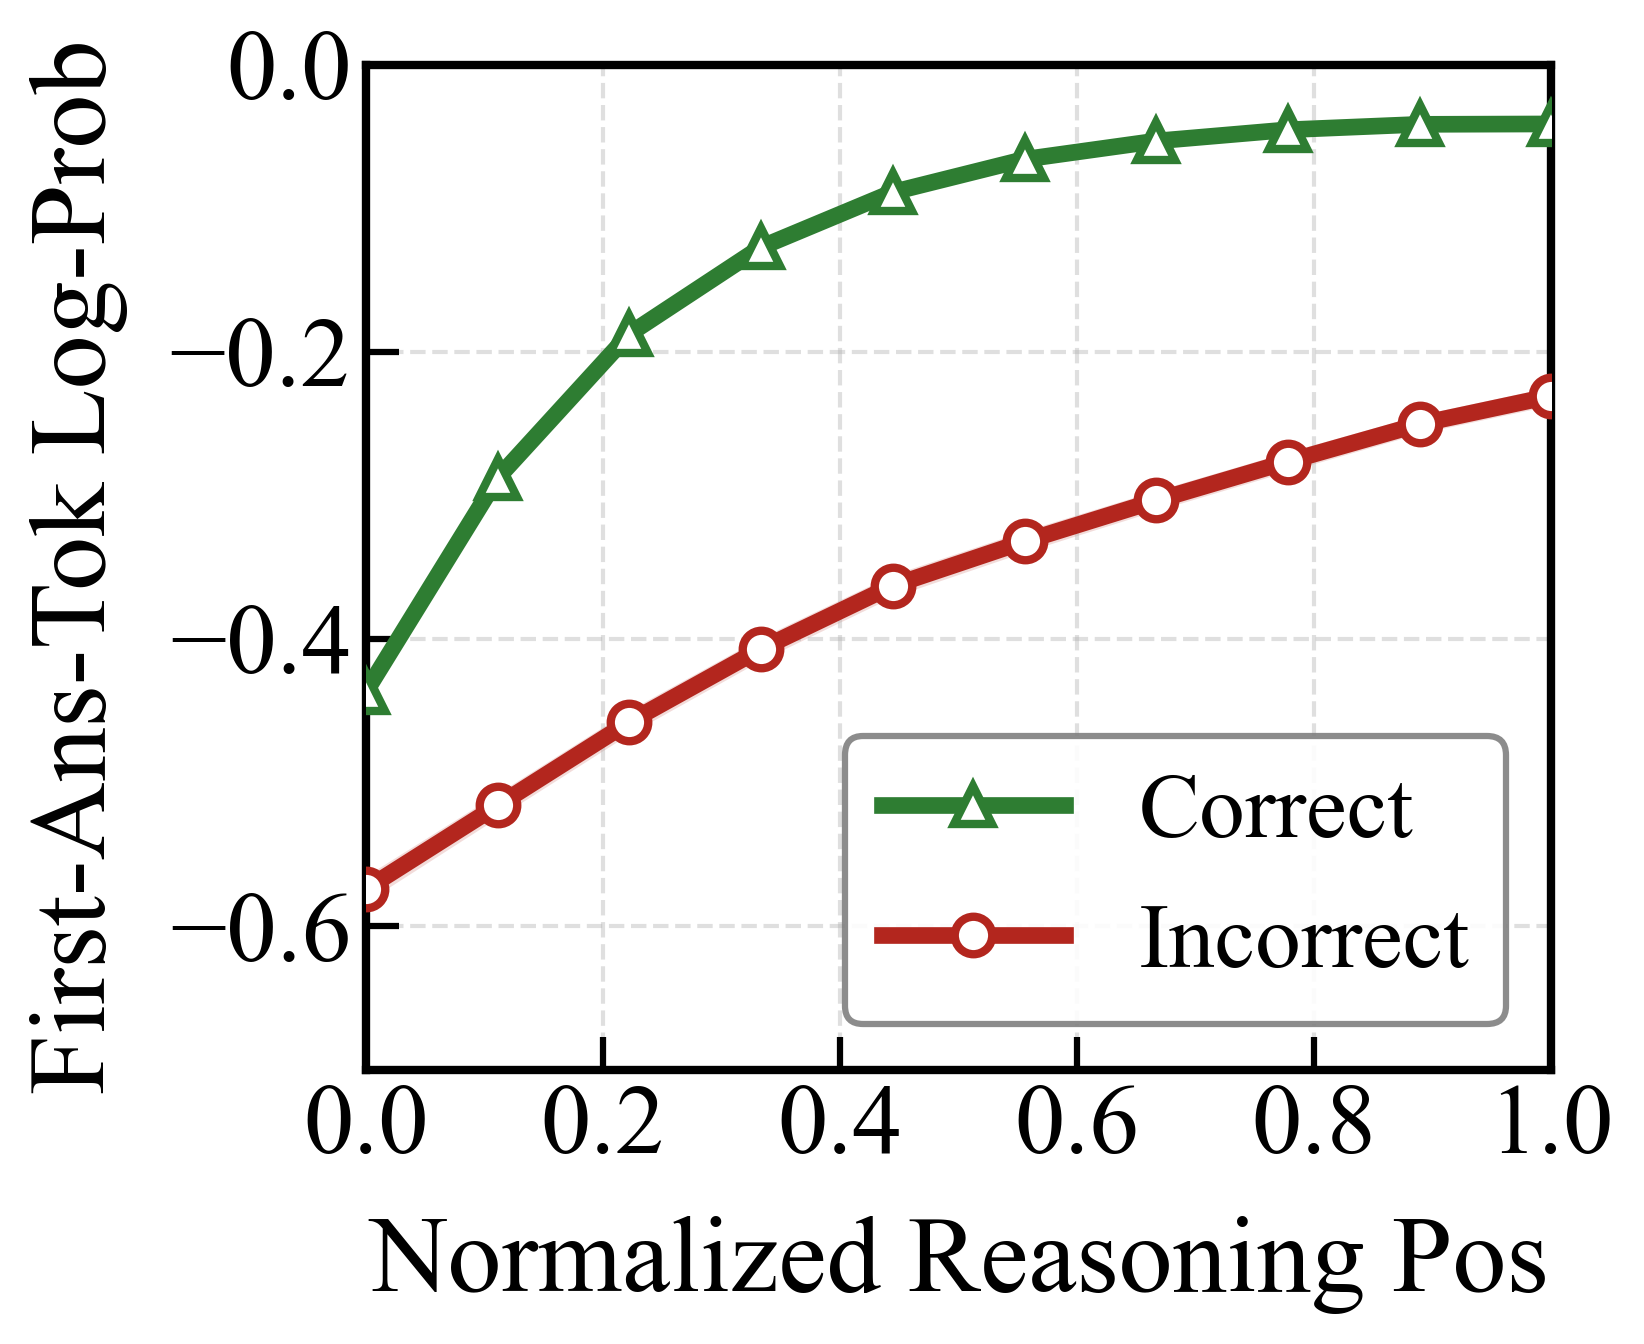

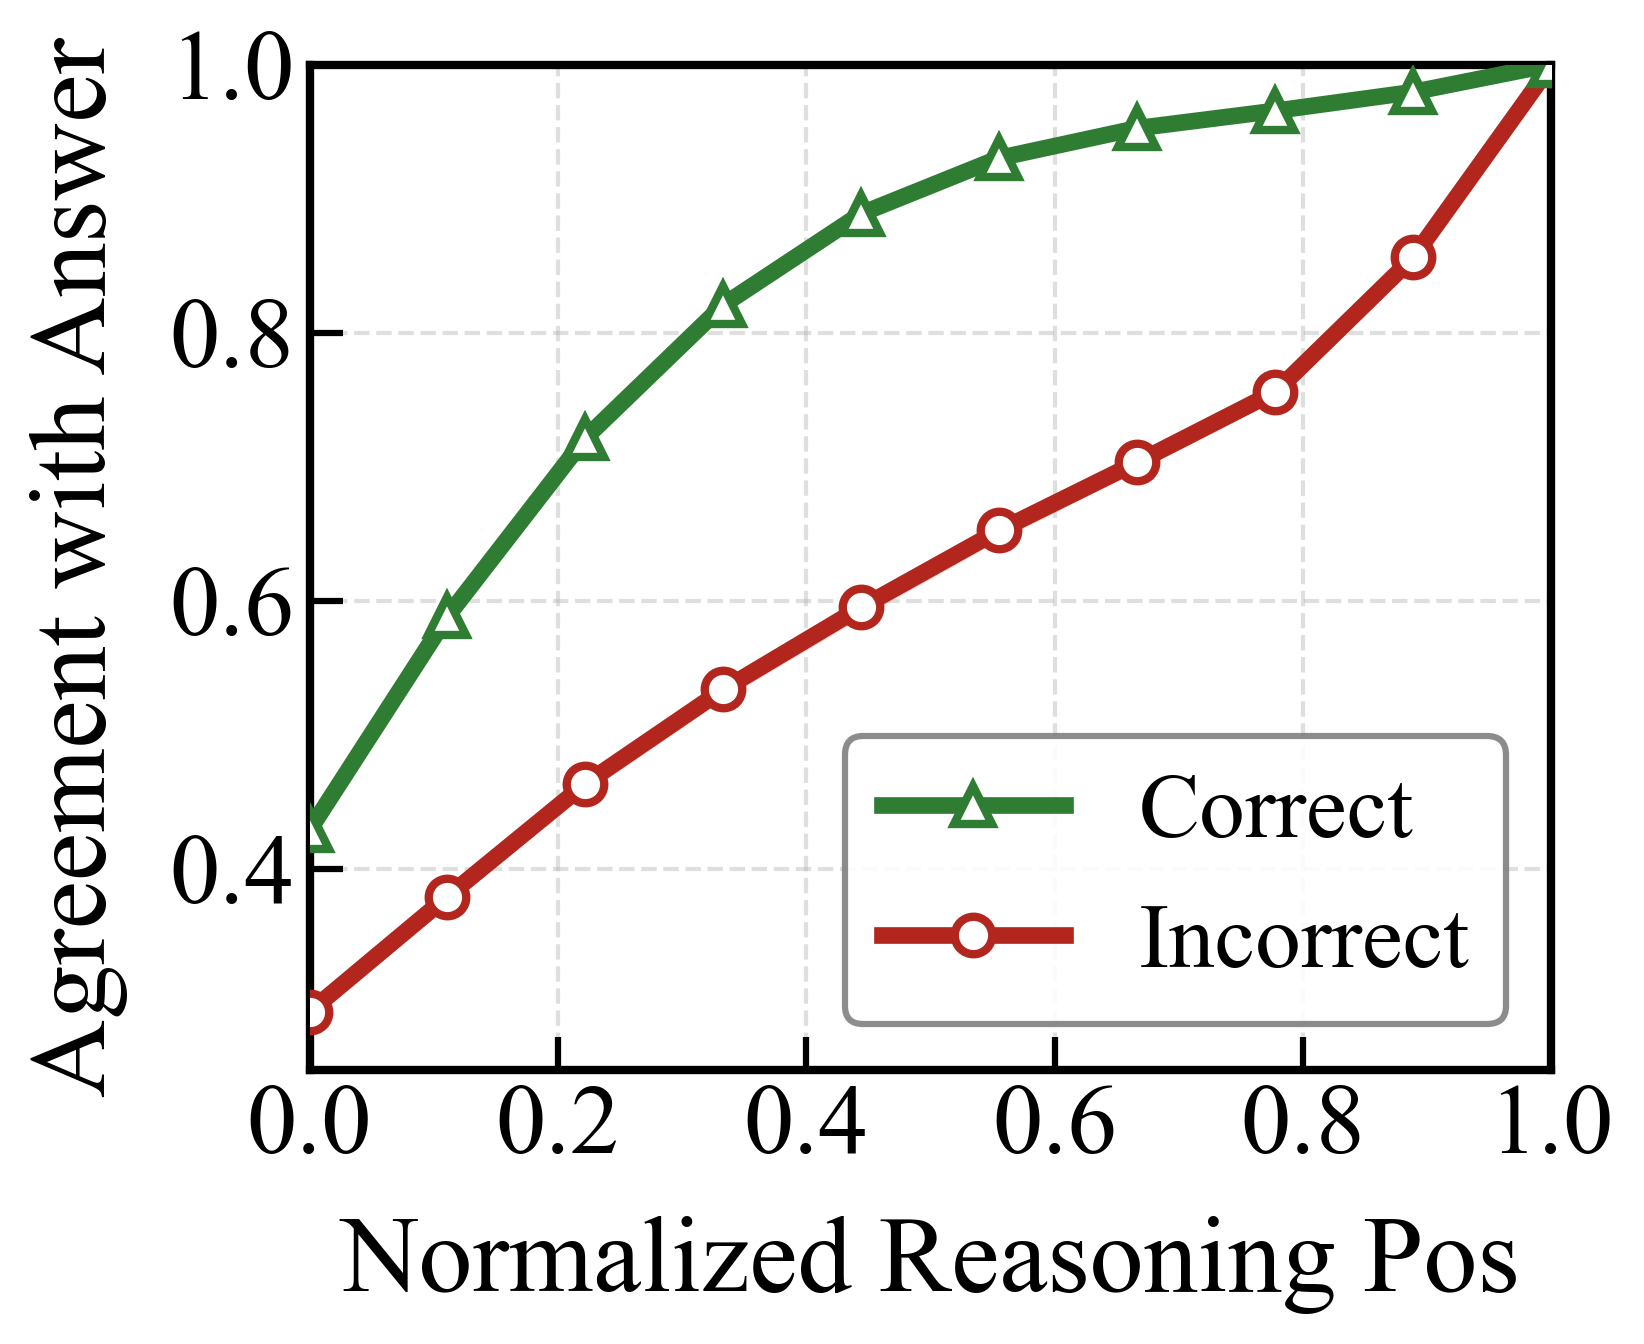

In [31]:
def resample(values, grid=10):
    values = [v for v in values if v is not None]
    if not values:
        return np.full(grid, np.nan)
    if len(values) == 1:
        return np.full(grid, values[0])
    return np.interp(np.linspace(0, 1, grid), np.linspace(0, 1, len(values)), values)

tags = sorted(json.loads((EXP_ROOT / 'master_table.json').read_text()).keys())
confidence = {0: [], 1: []}
identity = {0: [], 1: []}
for tag in tags:
    records = json.loads((EXP_ROOT / 'conf' / f'{tag}_conf.json').read_text())
    labels = json.loads((EXP_ROOT / 'labels' / f'{tag}.json').read_text())
    for record in records:
        if record['id'] not in labels or not record['intermediate']:
            continue
        y = int(labels[record['id']])
        answers = [step['neutral'] for step in record['intermediate']]
        final = answers[-1]
        agreement = [float(a is not None and final is not None and _eq(a, final)) for a in answers]
        logprob = [step.get('neutral_lp') for step in record['intermediate']]
        confidence[y].append(resample(logprob))
        identity[y].append(resample(agreement))

x = np.linspace(0, 1, 10)
styles = {1: ('Correct', '#2E7D32', '^'), 0: ('Incorrect', '#B3261E', 'o')}

def trajectory_plot(groups, ylabel, path, ylim=None):
    # Match the EnergyMamba curve_1 presentation style.
    fig, ax = plt.subplots(figsize=(6, 5))
    for y in [1, 0]:
        label, color, marker = styles[y]
        values = np.asarray(groups[y], float)
        mean = np.nanmean(values, axis=0)
        sem = np.nanstd(values, axis=0) / np.sqrt(len(values))
        ax.plot(x, mean, color=color, lw=4, marker=marker, markersize=9,
                markerfacecolor='white', markeredgewidth=2, label=label, zorder=3+y)
        ax.fill_between(x, mean-sem, mean+sem, color=color, alpha=.16, linewidth=0)
    ax.set_xlabel('Normalized Reasoning Pos', fontsize=26, fontweight='bold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=26, fontweight='bold', labelpad=10)
    ax.set_xlim(0, 1)
    if ylim is not None: ax.set_ylim(*ylim)
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.tick_params(axis='both', which='major', labelsize=24, direction='in', length=8, width=1.5)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.grid(True, which='major', linestyle='--', linewidth=1, alpha=.4, zorder=0)
    legend = ax.legend(fontsize=22, loc='lower right', frameon=True, framealpha=.9, edgecolor='gray')
    legend.get_frame().set_linewidth(1.5)
    fig.tight_layout()
    fig.savefig(out / path, bbox_inches='tight')
    plt.show()

trajectory_plot(confidence, 'First-Ans-Tok Log-Prob', 'confidence_trajectory.pdf', (-0.7, 0))
trajectory_plot(identity, 'Agreement with Answer', 'identity_trajectory.pdf', (.25, 1.00))